In [2]:
import pandas as pd
train_df = pd.read_csv("C:\\Users\\NAMAN\\Desktop\\kaggle_comp\\src\\notebooks\\data\\train_cleaned.csv")
test_df = pd.read_csv("C:\\Users\\NAMAN\\Desktop\\kaggle_comp\\src\\notebooks\\data\\test_cleaned.csv")

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
X = train_df.drop(columns=["Price"])  # Drop target from training features
y = train_df["Price"]
test_ids = test_df["id"]  # Store test IDs for submission

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
test_scaled = scaler.transform(test_df.drop(columns=["id"]))

In [6]:
# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [7]:
def train_xgb(params):
    """Trains an XGBoost model and returns it."""
    model = xgb.XGBRegressor(**params, objective="reg:squarederror", random_state=42)
    model.fit(X_train, y_train)
    return model


In [8]:
import numpy as np
import xgboost as xgb
from xgboost import XGBRegressor,plot_importance
import catboost as cb
import optuna
from sklearn.metrics import mean_squared_error

def objective_xgb(trial):
    params = {
        "n_estimators": 70,
        "eval_metric": "rmse",
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.1),
        "min_child_weight": trial.suggest_int("min_child_weight", 0.01, 1),
        "subsample": trial.suggest_loguniform("subsample", 0.1, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.1, 1),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.1, 1),
        "colsample_bynode": trial.suggest_float("colsample_bynode", 0.1, 1),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.01, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.01, 1)
    }
    
    model = train_xgb(params)  # Call reusable function
    
    y_pred = model.predict(X_val)
    return mean_squared_error(y_val, y_pred, squared=False)


study_xgb = optuna.create_study(direction="minimize")
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_xgb.optimize(objective_xgb, n_trials=20,show_progress_bar=True)
best_params_xgb = study_xgb.best_params

best_params_xgb = study_xgb.best_params
xgb_model = train_xgb(best_params_xgb)  # Use the same function


[I 2025-02-16 01:13:14,873] A new study created in memory with name: no-name-564c067d-5b0c-4024-a2b3-a3e88f53f6e0


  0%|          | 0/20 [00:00<?, ?it/s]

C:\Users\NAMAN\AppData\Local\Temp\ipykernel_1468\3647973774.py:13: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.1),
C:\Users\NAMAN\AppData\Local\Temp\ipykernel_1468\3647973774.py:15: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "subsample": trial.suggest_loguniform("subsample", 0.1, 1.0),
C:\Users\NAMAN\AppData\Local\Temp\ipykernel_1468\3647973774.py:13: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "learning_rate": trial.suggest_loguniform("le

In [9]:
print("Best trail:", study_xgb.best_trials)

Best trail: [FrozenTrial(number=14, state=1, values=[38.80854328983594], datetime_start=datetime.datetime(2025, 2, 16, 1, 13, 50, 186499), datetime_complete=datetime.datetime(2025, 2, 16, 1, 13, 52, 800644), params={'max_depth': 4, 'learning_rate': 0.09044453971702866, 'min_child_weight': 1, 'subsample': 0.6111609737777934, 'colsample_bylevel': 0.8755367634136532, 'colsample_bytree': 0.8079231282063831, 'colsample_bynode': 0.8767144571426669, 'reg_alpha': 0.6641528136872283, 'reg_lambda': 0.2618546272306435}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'max_depth': IntDistribution(high=7, log=False, low=3, step=1), 'learning_rate': FloatDistribution(high=0.1, log=True, low=0.01, step=None), 'min_child_weight': IntDistribution(high=1, log=False, low=0, step=1), 'subsample': FloatDistribution(high=1.0, log=True, low=0.1, step=None), 'colsample_bylevel': FloatDistribution(high=1.0, log=False, low=0.1, step=None), 'colsample_bytree': FloatDistribution(high=1.0, l

In [10]:
print("Best parameters:", study_xgb.best_params)

Best parameters: {'max_depth': 4, 'learning_rate': 0.09044453971702866, 'min_child_weight': 1, 'subsample': 0.6111609737777934, 'colsample_bylevel': 0.8755367634136532, 'colsample_bytree': 0.8079231282063831, 'colsample_bynode': 0.8767144571426669, 'reg_alpha': 0.6641528136872283, 'reg_lambda': 0.2618546272306435}


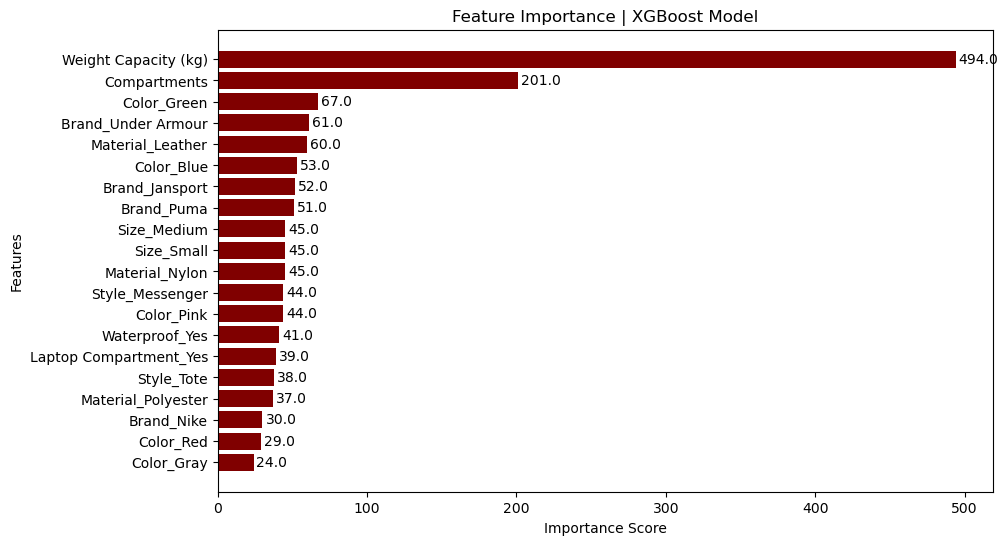

In [11]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb

# Assuming 'X' is your feature matrix used for training
feature_names = X.columns  # Extract actual feature names

# Get feature importance from trained XGBoost model
importance = xgb_model.get_booster().get_score(importance_type="weight")

# Convert to DataFrame
importance_df = pd.DataFrame(
    {"Feature": importance.keys(), "Importance": importance.values()}
).sort_values(by="Importance", ascending=False)

# Map feature numbers to actual feature names
importance_df["Feature"] = importance_df["Feature"].map(lambda x: feature_names[int(x[1:])])

# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="maroon")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance | XGBoost Model")
plt.gca().invert_yaxis()  # Invert for highest at top

# Add value labels
for index, value in enumerate(importance_df["Importance"]):
    plt.text(value + 2, index, str(value), va="center")

plt.show()


***CATBOOST TIME***

In [12]:
X = train_df.drop(columns=["Price"])
y = train_df["Price"]

In [13]:
# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [15]:
cat_features = [col for col in X.columns if X[col].dtype == "object"]

In [16]:
from catboost import CatBoostRegressor
def objective(trial):
    
    params = {
        "iterations": 100,  
        "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.1),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_loguniform("l2_leaf_reg", 1e-3, 10.0),  # Regularization
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength": trial.suggest_int("random_strength", 0, 50),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "verbose": 200
    }
    
    model = CatBoostRegressor(**params, cat_features=cat_features)
    
    model.fit(X_train_scaled, y_train, eval_set=(X_val_scaled, y_val), early_stopping_rounds=100, verbose=200)
    
    y_pred = model.predict(X_val_scaled)
    return mean_squared_error(y_val, y_pred, squared=False)  # RMSE




# Run Optuna optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20, show_progress_bar=True)

# Best parameters
best_params = study.best_params
print("Best parameters:", best_params)

  0%|          | 0/20 [00:00<?, ?it/s]

C:\Users\NAMAN\AppData\Local\Temp\ipykernel_1468\2998606563.py:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.1),
C:\Users\NAMAN\AppData\Local\Temp\ipykernel_1468\2998606563.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "l2_leaf_reg": trial.suggest_loguniform("l2_leaf_reg", 1e-3, 10.0),  # Regularization


0:	learn: 38.8741160	test: 38.8404424	best: 38.8404424 (0)	total: 198ms	remaining: 19.6s
99:	learn: 38.8422838	test: 38.8161939	best: 38.8161939 (99)	total: 5.99s	remaining: 0us

bestTest = 38.81619385
bestIteration = 99



C:\Users\NAMAN\AppData\Local\Temp\ipykernel_1468\2998606563.py:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.1),
C:\Users\NAMAN\AppData\Local\Temp\ipykernel_1468\2998606563.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "l2_leaf_reg": trial.suggest_loguniform("l2_leaf_reg", 1e-3, 10.0),  # Regularization


0:	learn: 38.8739007	test: 38.8402540	best: 38.8402540 (0)	total: 79.2ms	remaining: 7.84s
99:	learn: 38.8575917	test: 38.8284370	best: 38.8284370 (99)	total: 6.58s	remaining: 0us

bestTest = 38.82843702
bestIteration = 99



...

0:	learn: 38.8730825	test: 38.8396885	best: 38.8396885 (0)	total: 56.2ms	remaining: 5.57s
99:	learn: 38.8435210	test: 38.8187426	best: 38.8187426 (99)	total: 5.64s	remaining: 0us

bestTest = 38.81874262
bestIteration = 99



C:\Users\NAMAN\AppData\Local\Temp\ipykernel_1468\2998606563.py:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.1),
C:\Users\NAMAN\AppData\Local\Temp\ipykernel_1468\2998606563.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "l2_leaf_reg": trial.suggest_loguniform("l2_leaf_reg", 1e-3, 10.0),  # Regularization


0:	learn: 38.8737801	test: 38.8401085	best: 38.8401085 (0)	total: 39.9ms	remaining: 3.95s
99:	learn: 38.8339052	test: 38.8187864	best: 38.8187864 (99)	total: 6.47s	remaining: 0us

bestTest = 38.81878644
bestIteration = 99



C:\Users\NAMAN\AppData\Local\Temp\ipykernel_1468\2998606563.py:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.1),
C:\Users\NAMAN\AppData\Local\Temp\ipykernel_1468\2998606563.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "l2_leaf_reg": trial.suggest_loguniform("l2_leaf_reg", 1e-3, 10.0),  # Regularization


0:	learn: 38.8739613	test: 38.8402881	best: 38.8402881 (0)	total: 67.7ms	remaining: 6.71s
99:	learn: 38.8486842	test: 38.8229402	best: 38.8229402 (99)	total: 6.86s	remaining: 0us

bestTest = 38.82294017
bestIteration = 99

Best parameters: {'learning_rate': 0.03526518305385116, 'depth': 7, 'l2_leaf_reg': 0.011381662903063323, 'bagging_temperature': 0.33716692341204874, 'random_strength': 0, 'border_count': 186, 'subsample': 0.6934921513730168, 'colsample_bylevel': 0.9140949283503157}


In [19]:
from sklearn.model_selection import KFold

# Define K-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = []

for train_index, test_index in kf.split(X):  
    X_train, X_val = X.iloc[train_index], X.iloc[test_index]
    y_train, y_val = y.iloc[train_index], y.iloc[test_index]
    
    model = CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=6, loss_function="RMSE", verbose=False)
    model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)
    
    y_pred = model.predict(X_val)
    rmse = mean_squared_error(y_val, y_pred, squared=False)  # RMSE calculation
    rmse_scores.append(rmse)

# Final Performance Score
print(f"Mean RMSE: {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")

Mean RMSE: 38.8331 ± 0.0349


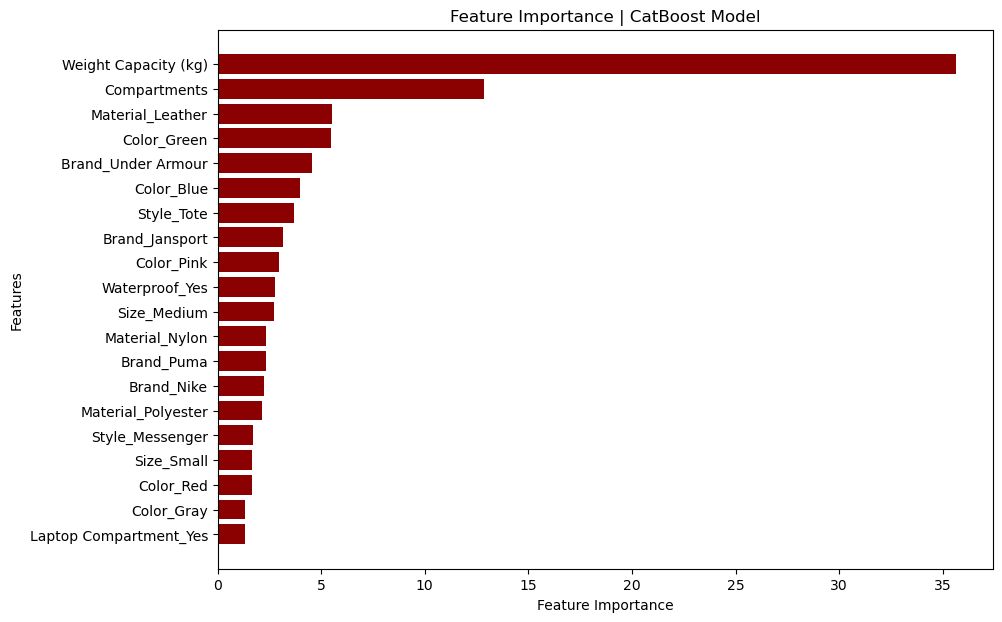

In [ ]:
feature_importances = model.get_feature_importance()
feature_names = X_train.columns  # Use the same feature names from your dataset

# Create a DataFrame for sorting
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 7))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='darkred')
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance | CatBoost Model")
plt.gca().invert_yaxis()  # Invert to show the most important at the top
plt.show()

In [ ]:
# Ensure test data is preprocessed the same way as train data
test_scaled = scaler.transform(test_df.drop(columns=["id"], errors="ignore"))

# Make predictions using the trained model (CatBoost or XGBoost)
predictions = model.predict(test_scaled)

# Ensure predictions are in a DataFrame with required columns
submission = pd.DataFrame({
    "id": test_df["id"],  # Retain the 'id' column from test data
    "Price": predictions  # Predicted prices
})

# Save to CSV in the correct format
submission.to_csv("submission.csv", index=False)

print("Submission file 'submission.csv' created successfully!")